Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.io import loadmat
from scipy.special import expit
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
import matplotlib as mpl

Functions

In [2]:
def read_file(filepath):
    with xr.open_dataset(filepath) as ds:
        return ds.load()

def logistic(x, L, x0, k, b):
    return b + L * expit(-(x - x0) * k)

def resid(theta, x, y):
    L, x0, k, b = theta
    return logistic(x, L, x0, k, b) - y

def create_arctic_dataset(ds, min_lat=60, max_lat=90, step_size=5):
    """Create a dataset with Arctic latitude and longitude bands.
    
    Args:
        ds: Input xarray dataset
        min_lat: Minimum latitude (default 60)
        max_lat: Maximum latitude (default 90) 
        step_size: Size of latitude bands (default 5)
    
    Returns:
        xarray Dataset with Arctic latitude and longitude bands
    """
    # Define latitude bins
    lat_bins = [(lat, lat+step_size) for lat in range(min_lat, max_lat, step_size)]
    
    # Define longitude bins for different Arctic regions
    lon_bins = [
        (330, 44.999, "North Atlantic"),    
        (45, 164.999, "Eurasia"),  
        (165, 219.999, "Pacific"),   
        (220, 329.999, "Greenland/Canada"),
    ]
    
    # First create latitude bands
    lat_binned = xr.concat([
        ds.sel(
            lat=slice(lat_start, lat_end if (lat_end == max_lat) else lat_end-0.001),
        ).assign_coords(lat_band=f"{lat_start}-{lat_end}")
        for lat_start, lat_end in lat_bins
    ], dim="lat_band", join="outer")
    
    # Then create longitude bands within each latitude band
    datasets = []
    for lon_start, lon_end, region_name in lon_bins:
        if lon_start > lon_end:  # Handle wrapping around 0°
            lon_selection = lat_binned.sel(lon=slice(lon_start, 360)).combine_first(
                lat_binned.sel(lon=slice(0, lon_end))
            )
        else:
            lon_selection = lat_binned.sel(lon=slice(lon_start, lon_end))
            
        lon_selection = lon_selection.assign_coords(
            lon_band=region_name
        )
        datasets.append(lon_selection)
        
    return xr.concat(datasets, dim="lon_band", join="outer")

def calculate_preindustrial_temp(ds, lat_band, lon_band):
    """Calculate pre-industrial (1850-1900) average temperature for a given latitude and longitude band.
    
    Args:
        ds: Arctic dataset created by create_arctic_dataset()
        lat_band: Latitude band string (e.g. '60-70')
        lon_band: Longitude band string (e.g. '330-45')
        
    Returns:
        Pre-industrial average temperature for the specified latitude and longitude band
    """
    x = ds.sel(lat_band=lat_band, lon_band=lon_band)
    return x.weighted(np.cos(np.deg2rad(x.lat))).mean(
        dim=['lat', 'lon']
    ).sel(
        time=slice('1850', '1900')
    ).mean(
        dim='time'
    ).tas.item()

def calculate_temperature_anomalies(ds, ds_baseline, start_year='1900', end_year='2098'):
    """Calculate temperature anomalies for each latitude and longitude band relative to pre-industrial period.
    
    Args:
        ds: Arctic dataset created by create_arctic_dataset()
        start_year: Start year for anomaly calculation (default '1900') 
        end_year: End year for anomaly calculation (default '2099')
        
    Returns:
        xarray DataArray with temperature anomalies for each latitude and longitude band
    """
    # Get unique latitude and longitude bands from the dataset
    lat_bands = ds.lat_band.values
    lon_bands = ds.lon_band.values
    anomalies = []

    for lon_band in lon_bands:
        lon_anomalies = []
        for lat_band in lat_bands:
            # print(lat_band)
            # print(lon_band)
            x = ds.sel(lat_band=lat_band, lon_band=lon_band)['tas']
            # print(x.lon)
            anomaly = (
                x.weighted(np.cos(np.deg2rad(x.lat))).mean(dim=('lat', 'lon')).sel(time=slice(start_year, end_year)) - 
                calculate_preindustrial_temp(ds_baseline, lat_band, lon_band)
            )#['tas']
            lon_anomalies.append(anomaly)
        # Combine latitude bands for this longitude
        lon_anomaly = xr.concat(lon_anomalies, dim='lat_band')
        anomalies.append(lon_anomaly)

    # Combine all longitude bands
    return xr.concat(anomalies, dim='lon_band')

Read the fit parameters

In [3]:
logistic_fit_params = np.load('minimum_arctic_sea_ice_extent_sigmoid_fit_parameters.npy') # read fit parameters
logistic_fit_params.shape

(4, 4, 6, 9216)

Read the desired data

In [4]:
tas_baseline = read_file('../../../sai-simulator-internal/data/processed/tas/output_gauss-baseline.nc') # to get pre-industrial temperature
tas_arctic_baseline = create_arctic_dataset(tas_baseline) # create arctic dataset

emulated_tas = loadmat('../data/CIDER_patterns_for_Ali_2.mat')
emulated_tas = emulated_tas['CIDER_patterns_for_Ali'].mean(axis=-1)[:,:,-20:]

lat = tas_baseline.lat.values
lon = tas_baseline.lon.values
years = np.arange(2050, 2070)  # 20 years

# Ensure emulated_tas is in (time, lat, lon) order regardless of input shape.
# Accepts input as (lat, lon, time), (lon, lat, time), or (any order), intelligently infers and rearranges.
def to_time_lat_lon(arr, lat_vals, lon_vals, time_vals):
    shape = arr.shape
    axes = {dim: None for dim in ["lat", "lon", "time"]}
    # Check for axis matches by dimension
    for i, n in enumerate(shape):
        if n == len(lat_vals) and axes["lat"] is None:
            axes["lat"] = i
        elif n == len(lon_vals) and axes["lon"] is None:
            axes["lon"] = i
        elif n == len(time_vals) and axes["time"] is None:
            axes["time"] = i
    # If any is unmapped, fallback to (lat, lon, time) default
    if None in axes.values():
        axes = dict(lat=0, lon=1, time=2)
    # Transpose so (lat, lon, time) --> (time, lat, lon)
    order = [axes["time"], axes["lat"], axes["lon"]]
    return np.transpose(arr, order)

data_time_lat_lon = to_time_lat_lon(emulated_tas, lat, lon, years)

# Create a Dataset and add tas as a variable, now (time, lat, lon)
temp_xr = xr.Dataset(
    {
        "tas": (["time", "lat", "lon"], data_time_lat_lon)
    },
    coords={
        "lat": lat,
        "lon": lon,
        "time": years
    }
)

emulated_tas_ = np.squeeze(
    np.array(
        calculate_temperature_anomalies(
            create_arctic_dataset(temp_xr),
            tas_arctic_baseline,
            start_year=years[0], end_year=years[-1])
    )
)

Get the predicted values

In [5]:
number_of_lon_bands= logistic_fit_params.shape[1]
number_of_lat_bands= logistic_fit_params.shape[2]

predict_Y = np.zeros((number_of_lon_bands, number_of_lat_bands, len(years), logistic_fit_params.shape[-1])) 
for lat in range(number_of_lat_bands):
    for lon in range(number_of_lon_bands):
        for j in range(predict_Y.shape[-1]):
            popt = logistic_fit_params[:, lon, lat, j]  # Get parameters for this lat-lon band and grid point
            predict_Y[lon, lat, :, j] = logistic(emulated_tas_[lon, lat, :], *popt)  # Predict using the temperature points

Plotting the data

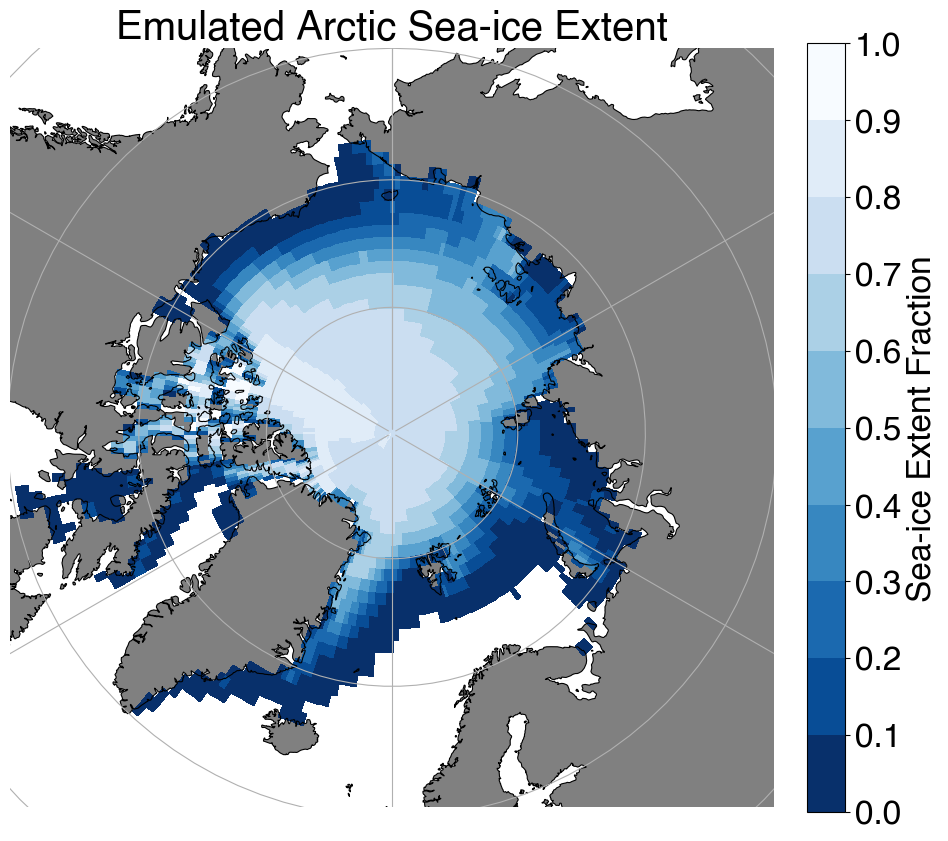

In [6]:
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size'] = 24

def calculate_Y_mean(Y):
    Y = Y.reshape(*Y.shape[:-1], 32, 288)
    Y = np.nansum(Y, axis=(0, 1))
    Y_mean = np.nanmean(Y, axis=0)
    Y_mean = np.where(Y_mean == 0, np.nan, Y_mean)
    return Y_mean

# Only compute Y_predict mean
predict_Y_mean = calculate_Y_mean(predict_Y)

# Get lat/lon values for Arctic region
lats = tas_baseline.sel(lat=slice(60, 90)).lat.values
lons = tas_baseline.sel(lon=slice(0, 360)).lon.values

# Create mesh grid for plotting
lon_mesh, lat_mesh = np.meshgrid(lons, lats)
fig = plt.figure(figsize=(10, 10))

# --- Blues colormap (leave nan as default) ---
cmap_blues = plt.cm.Blues_r
bounds_blues = np.linspace(0, 1, 11)
norm_blues = colors.BoundaryNorm(boundaries=bounds_blues, ncolors=cmap_blues.N, clip=True)

# Plot emulated values
ax = plt.subplot(111, projection=ccrs.NorthPolarStereo())
ax.coastlines(linewidth=0.8)
ax.gridlines(linewidth=0.8)
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='gray', edgecolor='none')
mesh = ax.pcolormesh(
    lon_mesh, lat_mesh, predict_Y_mean.reshape(32, 288),
    transform=ccrs.PlateCarree(),
    cmap=cmap_blues,
    norm=norm_blues,
    shading='auto'
)
cbar = plt.colorbar(mesh, ax=ax, label='Sea-ice Extent Fraction',
                     ticks=bounds_blues, boundaries=bounds_blues,
                     spacing='proportional', 
                     fraction=0.046, pad=0.04)
cbar.ax.tick_params()
cbar.set_label('Sea-ice Extent Fraction')
ax.set_title('Emulated Arctic Sea-ice Extent')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()